In [48]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import h5py
import cv2
from PIL import Image

file_path = r"C:\Users\Pranav Koka\Downloads\nyu_depth_v2_labeled.mat"

# Camera intrinsics for NYU Depth V2 (as provided)
K = np.array([
    [518.8579, 0, 325.5824],
    [0, 519.4696, 253.7362],
    [0, 0, 1]
])

In [2]:
with h5py.File(file_path, "r") as f:
    rgb_images = np.array(f["images"])  # Shape: (N, 3, 640, 480)
    depth_maps = np.array(f["depths"])  # Shape: (N, 640, 480)

print("RGB Images Shape:", rgb_images.shape)
print("Depth Maps Shape:", depth_maps.shape)

RGB Images Shape: (1449, 3, 640, 480)
Depth Maps Shape: (1449, 640, 480)


In [39]:
index = 1  # Select a frame
rgb = rgb_images[index]  # (3, 640, 480)
depth = depth_maps[index]  # (640, 480)
print("RGB Image Shape (Before Resize):", rgb.shape)
print("Depth Map Shape:", depth.shape)

RGB Image Shape (Before Resize): (3, 640, 480)
Depth Map Shape: (640, 480)


In [46]:
depth.min(), depth.max()

(1.1237347, 2.609266)

In [40]:
# Transpose to (H, W, C)
rgb = np.transpose(rgb, (1, 2, 0))  # Shape is now (640, 480, 3)
print("RGB Image Shape (After Transpose):", rgb.shape)
print("RGB Data Type:", rgb.dtype)

# Resize RGB to match depth resolution (640, 480)
rgb_resized = cv2.resize(rgb, (depth.shape[1], depth.shape[0]))  # Resizing to (640, 480)

RGB Image Shape (After Transpose): (640, 480, 3)
RGB Data Type: uint8


In [41]:
rgb_resized.shape

(640, 480, 3)

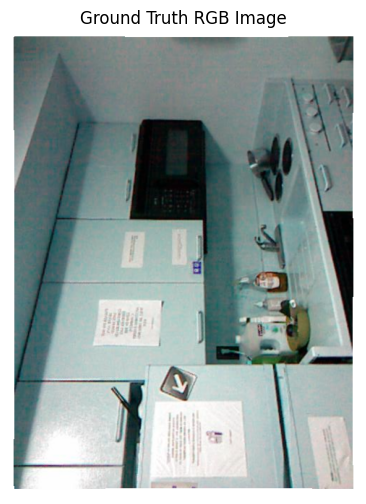

In [42]:
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(rgb_resized, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Ground Truth RGB Image")
plt.show()

In [54]:
img_bgr = cv2.imread(r"C:\Users\Pranav Koka\Downloads\12 (1).png")

football_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

football_rgb.shape

(1080, 1920, 3)

In [57]:
football_rel_depth_image = Image.open(r"C:\Users\Pranav Koka\Downloads\12.png")
football_rel_depth = np.array(football_rel_depth_image)
football_rel_depth

array([[50075, 50075, 50081, ..., 51458, 51451, 51412],
       [50075, 50081, 50081, ..., 51451, 51451, 51451],
       [50075, 50081, 50081, ..., 51458, 51451, 51451],
       ...,
       [34497, 34497, 34497, ..., 34497, 34497, 34497],
       [34477, 34477, 34477, ..., 34477, 34477, 34477],
       [34458, 34458, 34458, ..., 34458, 34458, 34458]])

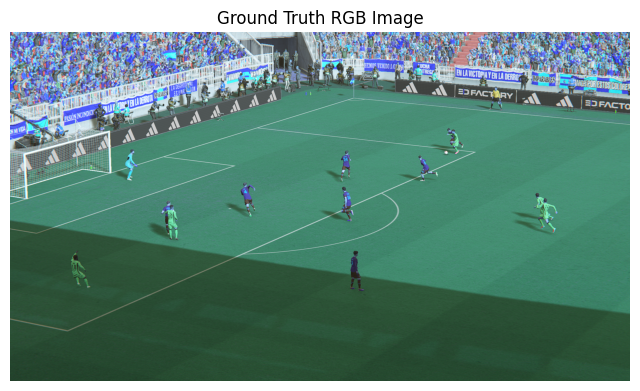

In [79]:
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(football_rgb, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Ground Truth RGB Image")
plt.show()

In [7]:
def depth_to_point_cloud(depth, rgb, K):
    """Convert depth map to 3D point cloud using camera intrinsics"""
    h, w = depth.shape
    fx, fy = K[0, 0], K[1, 1]  # Focal lengths
    cx, cy = K[0, 2], K[1, 2]  # Principal point

    # Create a mesh grid of pixel coordinates
    u, v = np.meshgrid(np.arange(w), np.arange(h))

    # Compute normalized camera coordinates
    X = (u - cx) * depth / fx
    Y = (v - cy) * depth / fy
    Z = depth

    # Stack into (N, 3) format
    points = np.stack((X, Y, Z), axis=-1).reshape(-1, 3)
    
    # Get corresponding RGB colors
    colors = rgb.reshape(-1, 3) / 255.0  # Normalize to [0, 1]

    return points, colors

In [8]:
# Generate point cloud
points, colors = depth_to_point_cloud(depth, rgb_resized, K)

# Convert to Open3D format
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)

# Visualize the point cloud
o3d.visualization.draw_geometries([pcd], zoom=0.5, front=[0, 0, -1], lookat=[0, 0, 0], up=[0, -1, 0])


The 3d reconstruction above was done using gt rgb, gt depth, and gt k

In [9]:
import torch
from PIL import Image
from depth_pro import depth_pro
from depth_pro.network.decoder import MultiresConvDecoder
from depth_pro.network.encoder import DepthProEncoder
from depth_pro.network.fov import FOVNetwork

checkpoint_path = "C:/Users/Pranav Koka/ml-depth-pro/checkpoints/depth_pro.pt"
config = depth_pro.DepthProConfig(
    checkpoint_uri=checkpoint_path,
    patch_encoder_preset="dinov2l16_384",
    image_encoder_preset="dinov2l16_384",
    decoder_features=256,
    use_fov_head=True,
    fov_encoder_preset="dinov2l16_384"
)
# Load the model state dictionary
model, transform = depth_pro.create_model_and_transforms(config=config)
model.eval()


DepthPro(
  (encoder): DepthProEncoder(
    (patch_encoder): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): LayerScale()
          (drop_path1): Identity()
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linea

In [62]:
# Assuming your rgb image is stored as 'rgb' in numpy format
# Convert numpy array to PIL Image if needed
if isinstance(rgb, np.ndarray):
    rgb_image = Image.fromarray(rgb)

# If the image is in PIL format, proceed to transform
image = transform(rgb_image).unsqueeze(0)  # Add batch dimension


In [11]:
rgb.shape

(640, 480, 3)

In [12]:
# Provide the focal length (in pixels) - Modify this based on your data
f_px = torch.tensor([518.8579])  # Replace this with your actual focal length in pixels

# Run inference
with torch.no_grad():
    prediction = model.infer(image, f_px=f_px)
    depth_map = prediction["depth"]  # Depth map in meters
    focal_length_px = prediction["focallength_px"]  # Focal length in pixels

# Convert depth map to numpy array for further processing
depth_map = depth_map.cpu().numpy()

In [13]:
points, colors = depth_to_point_cloud(depth_map, rgb_resized, K)

# Convert to Open3D format
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)

# Visualize the point cloud
o3d.visualization.draw_geometries([pcd], zoom=0.5, front=[0, 0, -1], lookat=[0, 0, 0], up=[0, -1, 0])

The 3d reconstruction above was done using gt rgb, pred depth, and gt k

In [14]:
with torch.no_grad():
    prediction = model.infer(image, f_px=None)  # Setting f_px=None triggers intrinsic prediction
    predicted_f_px = prediction["focallength_px"].item()  # This is the predicted focal length in pixels

print("Predicted Focal Length (in pixels):", predicted_f_px)


Predicted Focal Length (in pixels): 423.83917236328125


In [15]:
rgb.shape

(640, 480, 3)

In [16]:
H, W, _ = rgb.shape

# Use the predicted focal length
f_px = predicted_f_px  # Obtained from the DepthPro model's inference

# Create the intrinsic matrix K
K_pred = np.array([
    [f_px, 0, H / 2],
    [0, f_px, W / 2],
    [0, 0, 1]
])

print("Constructed Intrinsic Matrix K:")
print(K_pred)

Constructed Intrinsic Matrix K:
[[423.83917236   0.         320.        ]
 [  0.         423.83917236 240.        ]
 [  0.           0.           1.        ]]


In [17]:
points, colors = depth_to_point_cloud(depth, rgb_resized, K_pred)

# Convert to Open3D format
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)

# Visualize the point cloud
o3d.visualization.draw_geometries([pcd], zoom=0.5, front=[0, 0, -1], lookat=[0, 0, 0], up=[0, -1, 0])

The 3d reconstruction above was done using gt rgb, gt depth, and pred k

In [64]:
# Assuming your rgb image is stored as 'rgb' in numpy format
# Convert numpy array to PIL Image if needed
if isinstance(rgb, np.ndarray):
    rgb_image = Image.fromarray(rgb)

# If the image is in PIL format, proceed to transform
image = transform(rgb_image).unsqueeze(0)  # Add batch dimension

In [63]:
with torch.no_grad():
    prediction = model.infer(image, f_px=None)  # Setting f_px=None triggers intrinsic prediction
    depth_map_pred = prediction["depth"].cpu().numpy()
    predicted_f_px = prediction["focallength_px"].item()  # This is the predicted focal length in pixels

print("Predicted Focal Length (in pixels):", predicted_f_px)

H, W, _ = rgb.shape

# Use the predicted focal length
f_px = predicted_f_px

# Create the intrinsic matrix K
K_pred = np.array([
    [f_px, 0, H / 2],
    [0, f_px, W / 2],
    [0, 0, 1]
])

print("Constructed Intrinsic Matrix K:")
print(K_pred)

Predicted Focal Length (in pixels): 423.83917236328125
Constructed Intrinsic Matrix K:
[[423.83917236   0.         320.        ]
 [  0.         423.83917236 240.        ]
 [  0.           0.           1.        ]]


In [82]:
if isinstance(football_rgb, np.ndarray):
    football_rgb_image = Image.fromarray(football_rgb)

# If the image is in PIL format, proceed to transform
football_image = transform(football_rgb_image).unsqueeze(0)  # Add batch dimension

In [85]:
with torch.no_grad():
    prediction = model.infer(football_image, f_px=None)  # Setting f_px=None triggers intrinsic prediction
    depth_map_pred = prediction["depth"].cpu().numpy()
    predicted_f_px = prediction["focallength_px"].item()  # This is the predicted focal length in pixels

print("Predicted Focal Length (in pixels):", predicted_f_px)

H, W, _ = football_rgb.shape

# Use the predicted focal length
f_px = predicted_f_px

# Create the intrinsic matrix K
K_pred = np.array([
    [f_px, 0, H / 2],
    [0, f_px, W / 2],
    [0, 0, 1]
])

print("Constructed Intrinsic Matrix K:")
print(K_pred)

Predicted Focal Length (in pixels): 5007.2783203125
Constructed Intrinsic Matrix K:
[[5.00727832e+03 0.00000000e+00 5.40000000e+02]
 [0.00000000e+00 5.00727832e+03 9.60000000e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]


In [99]:
print(depth_map_pred.shape, depth_map_pred.dtype, depth_map_pred.min(), depth_map_pred.max())
print(football_rel_depth.shape, football_rel_depth.dtype, football_rel_depth.min(), football_rel_depth.max())

(1080, 1920) float32 16.143288 375.45334
(1080, 1920) int32 34458 52840


In [ ]:
depth_pred_rel = (depth_map_pred - depth_map_pred.min()) / (depth_map_pred.max() - depth_map_pred.min())
football_rel_depth_norm = (football_rel_depth - football_rel_depth.min()) / (football_rel_depth.max() - football_rel_depth.min())

In [110]:
depth_pred_rel.dtype, football_rel_depth_norm.dtype

(dtype('float32'), dtype('float64'))

In [ ]:
from scipy.stats import spearmanr

# Flatten
pred_flat = depth_pred_rel.flatten()
gt_flat = football_rel_depth_norm.flatten()

# Metrics
spearman_corr, _ = spearmanr(pred_flat, gt_flat)
mae = np.mean(np.abs(pred_flat - gt_flat))

print("Spearman Correlation:", spearman_corr)
print("Mean Absolute Error:", mae)

Spearman Correlation: 0.9989691257318675
Mean Absolute Error: 0.3734503750557966


In [103]:
gt_min = football_rel_depth.min()
gt_max = football_rel_depth.max()

# Normalize both using GT min-max range
depth_pred_norm = (depth_map_pred - gt_min) / (gt_max - gt_min)
gt_rel_norm = (football_rel_depth - gt_min) / (gt_max - gt_min)


In [106]:
# Flatten
pred_flat = depth_pred_norm.flatten()
gt_flat = gt_rel_norm.flatten()

# Metrics
spearman_corr, _ = spearmanr(pred_flat, gt_flat)
mae = np.mean(np.abs(pred_flat - gt_flat))

print("Spearman Correlation:", spearman_corr)
print("Mean Absolute Error:", mae)

Spearman Correlation: 0.9989691232028249
Mean Absolute Error: 2.4011917686705875


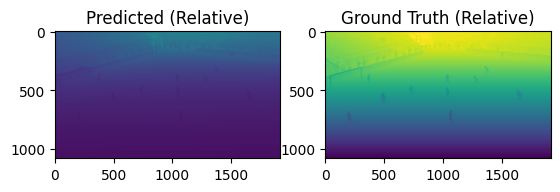

In [105]:
import matplotlib.pyplot as plt

plt.subplot(1, 2, 1)
plt.imshow(depth_pred_rel, cmap='viridis')
plt.title("Predicted (Relative)")

plt.subplot(1, 2, 2)
plt.imshow(football_rel_depth_norm, cmap='viridis')
plt.title("Ground Truth (Relative)")

plt.show()

In [114]:
points, colors = depth_to_point_cloud(depth_map_pred, football_rgb, K_pred)

# Convert to Open3D format
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)

# Visualize the point cloud
o3d.visualization.draw_geometries([pcd], zoom=0.000001, front=[0, 0, -1], lookat=[0, 0, 0], up=[0, -1, 0])

[Open3D WARNING] [ViewControl] SetViewPoint() failed because window height and width are not set.


In [112]:
vis = o3d.visualization.Visualizer()
vis.create_window()
vis.add_geometry(pcd)

# Get render option and set point size
render_option = vis.get_render_option()
render_option.point_size = 1.0  # Try values like 0.5, 1.0, 2.0 etc.

vis.run()
vis.destroy_window()


[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 


The 3d reconstruction above was done using gt rgb, pred depth, and pred k (both predicted with just the gt rgb)

In [20]:
import sys
sys.path.append("C:/Users/Pranav Koka/Marigold")

In [21]:
from marigold import MarigoldPipeline

In [22]:
pipe = MarigoldPipeline.from_pretrained('prs-eth/marigold-lcm-v1-0')
pipe = pipe.to("cpu")

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

In [23]:
denoising_steps = 4
ensemble_size = 5
processing_res = 768
match_input_res = True

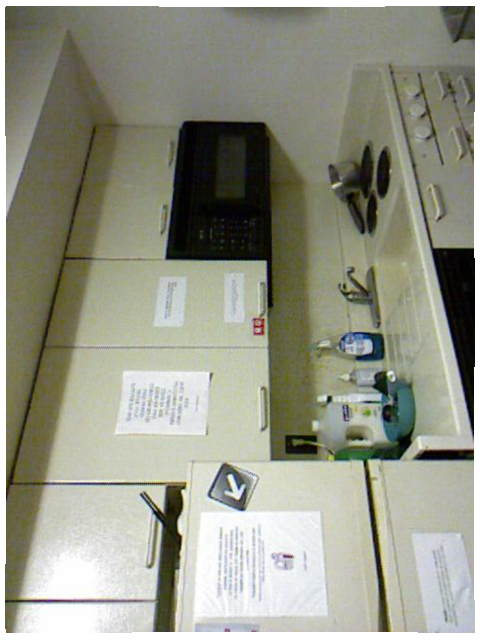

In [24]:
rgb_image

In [25]:
with torch.no_grad():
    pipeline_output = pipe(
        rgb_image,
        denoising_steps=denoising_steps,
        ensemble_size=ensemble_size,
        processing_res=processing_res,
        match_input_res=match_input_res,
        batch_size=0,
        color_map= "Spectral",
        show_progress_bar=True,
    )

  Inference batches:   0%|          | 0/5 [00:00<?, ?it/s]

    Diffusion denoising:   0%|          | 0/4 [00:00<?, ?it/s]

    Diffusion denoising:   0%|          | 0/4 [00:00<?, ?it/s]

    Diffusion denoising:   0%|          | 0/4 [00:00<?, ?it/s]

    Diffusion denoising:   0%|          | 0/4 [00:00<?, ?it/s]

    Diffusion denoising:   0%|          | 0/4 [00:00<?, ?it/s]

In [26]:
depth1 = pipeline_output.depth_np
depth1.min(), depth1.max()

(0.00013835153, 0.99856746)

In [27]:
depth.min(), depth.max()

(1.1237347, 2.609266)

In [28]:
depth_map.min(),depth_map.max()

(0.6209671, 2.009373)

In [29]:
depth_map_pred.min(),depth_map_pred.max()

(0.50724906, 1.6413953)

In [30]:
def scale_to_absolute(pred_rel, gt_abs):
    # Flatten to 1D and mask invalid values (e.g., zero in ground truth)
    mask = gt_abs > 0
    pred_rel_flat = pred_rel[mask]
    gt_abs_flat = gt_abs[mask]

    # Solve linear least squares: gt_abs ≈ a * pred_rel + b
    A = np.vstack([pred_rel_flat, np.ones_like(pred_rel_flat)]).T
    scale, shift = np.linalg.lstsq(A, gt_abs_flat, rcond=None)[0]

    return scale, shift

In [31]:
print(scale_to_absolute(depth1, depth))
pred_abs = scale_to_absolute(depth1,depth)[0]*depth1 + scale_to_absolute(depth1,depth)[1]
pred_abs.min(), pred_abs.max()

(1.3649737, 1.1699859)


(1.1701747, 2.5330043)

In [32]:
points, colors = depth_to_point_cloud(pred_abs, rgb_resized, K)

# Convert to Open3D format
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)

# Visualize the point cloud
o3d.visualization.draw_geometries([pcd], zoom=0.5, front=[0, 0, -1], lookat=[0, 0, 0], up=[0, -1, 0])

The 3d reconstruction above was done using gt rgb, pred marigold depth, and gt k